# SHAP Analysis — K562 inDecay Model

We explain the K562 pretrained MLP (`inputsize=61 → hidden=[128,64] → 1`).

**Feature layout (61 total):**
- Indices  0–13: 14 deletion-specific features (indel_size, ss, 3×ss-decay, MML1, MML2, proximal, distal, 3×dl-decay, del_intercept, n_coevent)
- Indices 14–21:  8 insertion-specific features (ins_length, complement, shift, full_complement, ins_intercept, n_coevent, right_nt_match, left_nt_match)
- Indices 22–24:  3 shared scalar features (guide_GC, mh_pixelsum_D, mh_pixelsum_P)
- Indices 25–60: 36 one-hot sequence features (9 bp × 4 nt around cut site)

**Data:** Features are computed from the 6234 SelfTarget scaffold oligos (for which reference sequences and indelgen files are available locally) using the same `ST_decayfeat_v5` pipeline as training.

In [1]:
%load_ext autoreload
%autoreload 2
import os, sys, pickle as pkl
import numpy as np
import pandas as pd
import torch
import shap
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from Bio import SeqIO

from inDecay import PATH, my_utils, alignmap
from inDecay.models import ST_DeepDecay
os.chdir(PATH.main_dir)

/rds/user/wz369/hpc-work/LIBS/mamba/envs/inDecay/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/rds/user/wz369/hpc-work/LIBS/mamba/envs/inDecay/lib/python3.11/site-packages/qrguide/transformation.py:25: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  label,rev_index,features,frame_shift = pkl.load(importlib.resources.open_binary("qrguide.utils", "model_prereq.pkl"))
/rds/user/wz369/hpc-work/LIBS/mamba/envs/inDecay/lib/python3.11/site-packages/qrguide/transformation.py:28: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  wb = pkl.lo

## 1. Define feature names

In [2]:
# Deletion-specific (14)
del_feat_names = [
    'del_size',
    'ss',
    'ss_decay_0.5k',
    'ss_decay_k',
    'ss_decay_1.5k',
    'MML1',
    'MML2',
    'proximal',
    'distal',
    'dl_decay_0.5k',
    'dl_decay_k',
    'dl_decay_1.5k',
    'del_intercept',
    'n_coevent_del',
]

# Insertion-specific (8)
ins_feat_names = [
    'ins_length',
    'complement',
    'shift',
    'full_complement',
    'ins_intercept',
    'n_coevent_ins',
    'right_nt_match',
    'left_nt_match',
]

# Shared scalar (3)
shared_scalar_names = [
    'guide_GC',
    'mh_pixelsum_D',
    'mh_pixelsum_P',
]

# One-hot sequence (36): 9 positions × 4 nucleotides
positions = list(range(-5, 4))  # -5,-4,-3,-2,-1,0,1,2,3
nts = ['A', 'C', 'G', 'T']
seq_feat_names = [f'seq_{p}_{nt}' for p in positions for nt in nts]

feature_names = del_feat_names + ins_feat_names + shared_scalar_names + seq_feat_names
assert len(feature_names) == 61, f"Expected 61 features, got {len(feature_names)}"

# Feature group membership for colour-coding SHAP plots
feat_group = (
    ['Deletion'] * 14 +
    ['Insertion'] * 8 +
    ['Shared scalar'] * 3 +
    ['Sequence context'] * 36
)
group_palette = {
    'Deletion':         '#677e98',
    'Insertion':        '#ceac2d',
    'Shared scalar':    '#c27c44',
    'Sequence context': '#9c9376',
}
feat_colors = [group_palette[g] for g in feat_group]
print('Feature names defined:', len(feature_names))

Feature names defined: 61


## 2. Load K562 pretrained model

In [3]:
ckpt_path = f"{PATH.main_dir}/pretrained/K562_featv5_pretrained.ckpt"
ckpt = torch.load(ckpt_path, map_location='cpu')
hp = ckpt['hyper_parameters']
print('Model hyper-parameters:', hp)

model = ST_DeepDecay(
    inputsize=hp['inputsize'],
    outputsize=hp.get('outputsize', 1),
    hidden=hp['hidden'],
    lr=hp['lr'],
    L1_lambda=hp['L1_lambda'],
    L2_lambda=hp['L2_lambda'],
)
model.load_state_dict(ckpt['state_dict'])
model.eval()

# Expose just the MLP regressor (without softmax) for SHAP
# del_regressor: Linear(61→128,Mish) → Linear(128→64,Mish) → Linear(64→1)
mlp = model.del_regressor
print('MLP layers:', mlp)

Model hyper-parameters: {'lr': 0.0003, 'L1_lambda': 0, 'L2_lambda': 0.0001, 'optim_class': 'Adam', 'inputsize': 61, 'outputsize': 1, 'hidden': [128, 64]}
MLP layers: Sequential(
  (0): Sequential(
    (0): Linear(in_features=61, out_features=128, bias=True)
    (1): Mish()
  )
  (1): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): Mish()
  )
  (2): Linear(in_features=64, out_features=1, bias=True)
)


/rds/user/wz369/hpc-work/LIBS/mamba/envs/inDecay/lib/python3.11/site-packages/torch/nn/modules/loss.py:44: UserWarning: size_average and reduce args will be deprecated, please use reduction='sum' instead.
  self.reduction: str = _Reduction.legacy_get_string(size_average, reduce)


## 3. Compute feature matrices for available SelfTarget oligos

The K562 test oligos are not in the local reference FASTA, so we use the 6234 SelfTarget scaffold oligos — the same source as model training — to build the SHAP background and explanation dataset.

In [5]:
k1, k2, h = 0.5, 0.6, 1.3  # same as training

ref_fasta = f"{PATH.main_dir}/data/SelfTarget_NewScaffold.fasta"
indelgen_dir = f"{PATH.main_dir}/data/somatic/Indelgen_result"

# Build a lookup: oligo_id -> (refseq, cutsite)
ref_lookup = {}
for record in SeqIO.parse(ref_fasta, 'fasta'):
    parts = record.id.split('_')
    oligo_id = parts[0]             # e.g. Oligo51529
    cutsite  = int(record.description.split()[1]) -3  # e.g. 33
    ref_lookup[oligo_id] = (str(record.seq), cutsite)

print(f"Reference FASTA: {len(ref_lookup)} oligos")

Reference FASTA: 6234 oligos


In [11]:
oligo_id = 'Oligo51529'
refseq, cutsite = ref_lookup[oligo_id]

# Locate indelgen file
guide = refseq[cutsite -3 - 17: cutsite ]  # 20 bp protospacer
indelgen_file = my_utils.get_indelgen_file(oligo_id, guide)

In [12]:
indelgen_file


'/rds/user/wz369/hpc-work/inDecay/data/somatic/Indelgen_result/Oligo51529_TGCTGGTTGGCGACCCTAAA_genindels.txt'

In [13]:
os.path.exists(indelgen_file)

True

In [42]:
TOP_K = 5   # keep top-k events per oligo by model-predicted score

X_all = []        # feature matrix rows (top-k per oligo)
meta_rows = []    # oligo + indel type metadata
indelgen_found = []
oligos = list(ref_lookup.keys())

mlp.eval()

for oligo_id in tqdm(oligos, desc='Computing features'):
    refseq, cutsite = ref_lookup[oligo_id]

    # Locate indelgen file — guide is the 20 bp protospacer ending at the cut site
    guide = refseq[cutsite - 20: cutsite]
    indelgen_file = my_utils.get_indelgen_file(oligo_id, guide)
    if not os.path.exists(indelgen_file):
        continue
    indelgen_found.append(oligo_id)

    # Read indelgen
    idfgen = pd.read_table(
        indelgen_file, skiprows=1, header=None, sep='	',
        names=['Identifier', 'n_coevent', 'loc', 'sequence'],
    )

    # Label microhomology (required by ST_decayfeat_v4)
    try:
        _, idfgen = alignmap.label_mh(refseq, cutsite, idfgen, mml_name='mh_length')
        _, idfgen = alignmap.label_mh(refseq, cutsite, idfgen, mml_name='mh_length2', panelty=0)
    except Exception:
        continue

    # Compute 61 features for all events in this oligo
    try:
        X5 = alignmap.ST_decayfeat_v5(idfgen, refseq, cutsite, k1, k2, h)
    except Exception:
        continue

    if X5.shape[1] != 61:
        continue

    # ── Filter to top-K events by model-predicted softmax probability ─────────
    # Explaining rare near-zero events adds noise. We keep only the TOP_K events
    # with the highest predicted probability per oligo — these are the predictions
    # that clinically matter.
    #
    # Note on softmax + SHAP validity:
    # log(p_i) = mlp(x_i) - LSE(all events in oligo)
    # Since LSE is constant w.r.t. x_i, gradients of log(p_i) w.r.t. x_i equal
    # gradients of mlp(x_i). So SHAP on the raw logit is identical to SHAP on
    # log(p_i) — the softmax does not change feature attributions.
    with torch.no_grad():
        X5_t   = torch.tensor(X5, dtype=torch.float32)
        logits = mlp(X5_t).squeeze()           # (N_events,)
        probs  = torch.softmax(logits, dim=0)  # (N_events,)
        n_keep = min(TOP_K, len(probs))
        top_idx = torch.topk(probs, k=n_keep).indices.numpy()

    X_all.append(X5[top_idx])

    for idx in top_idx:
        idf = idfgen['Identifier'].values[idx]
        meta_rows.append({'oligo': oligo_id, 'indel_type': idf[0]})

X_all   = np.vstack(X_all).astype(np.float32)
meta_df = pd.DataFrame(meta_rows)

print(f"Oligos with indelgen files : {len(indelgen_found)}")
print(f"Feature matrix (top-{TOP_K}/oligo): {X_all.shape}")
print(f"Indel type breakdown: {meta_df['indel_type'].value_counts().to_dict()}")

Computing features: 100%|██████████| 6234/6234 [08:39<00:00, 12.01it/s]


Oligos with indelgen files : 6197
Feature matrix (top-5/oligo): (30985, 61)
Indel type breakdown: {'D': 26335, 'I': 4650}


In [43]:
idfgen.head()

,Identifier,n_coevent,loc,sequence,mh_length,mh_length2
0,D10_L-10R1,1,"[(20,31,)]",GAGAACTGTTTTTAGTGGGACAGGGGCTGCCCTTCGTGGTGAGGTT...,0.0,0.0
1,D10_L-11R0,1,"[(19,30,)]",GAGAACTGTTTTTAGTGGGATAGGGGCTGCCCTTCGTGGTGAGGTT...,0.0,0.0
2,D10_L-1R10,1,"[(29,40,)]",GAGAACTGTTTTTAGTGGGACTACCTCTGGCCTTCGTGGTGAGGTT...,0.0,0.0
3,D10_L-5C3R9,4,"[(25,36,),(26,37,),(27,38,),(28,39,)]",GAGAACTGTTTTTAGTGGGACTACCTCTGCCCTTCGTGGTGAGGTT...,0.0,0.0
4,D10_L-6R5,1,"[(24,35,)]",GAGAACTGTTTTTAGTGGGACTACCGCTGCCCTTCGTGGTGAGGTT...,0.0,0.0


In [44]:
_, idfgen = alignmap.label_mh(refseq, cutsite, idfgen, mml_name='mh_length')
_, idfgen = alignmap.label_mh(refseq, cutsite, idfgen, mml_name='mh_length2', panelty=0)

In [45]:
X5 = alignmap.ST_decayfeat_v5(idfgen, refseq, cutsite, k1, k2, h)

## 4. Run SHAP (GradientExplainer on MLP raw logit)

We use `shap.GradientExplainer` on `model.del_regressor` (raw score before softmax).  
Background = 200-sample random subset; explanation set = 2000-sample random subset.

In [46]:
np.random.seed(42)

N_background = 200
N_explain    = 2000

# Stratified sampling to keep del/ins ratio natural
del_idx = np.where(meta_df['indel_type'].values == 'D')[0]
ins_idx = np.where(meta_df['indel_type'].values == 'I')[0]

bg_del = np.random.choice(del_idx, size=int(N_background * len(del_idx) / len(meta_df)), replace=False)
bg_ins = np.random.choice(ins_idx, size=N_background - len(bg_del), replace=False)
bg_idx = np.concatenate([bg_del, bg_ins])

ex_del = np.random.choice(np.setdiff1d(del_idx, bg_idx),
                          size=int(N_explain * len(del_idx) / len(meta_df)), replace=False)
ex_ins = np.random.choice(np.setdiff1d(ins_idx, bg_idx),
                          size=N_explain - len(ex_del), replace=False)
ex_idx = np.concatenate([ex_del, ex_ins])

X_background = torch.tensor(X_all[bg_idx])
X_explain    = torch.tensor(X_all[ex_idx])
meta_explain = meta_df.iloc[ex_idx].reset_index(drop=True)

print(f"Background: {X_background.shape}, Explanation: {X_explain.shape}")

explainer = shap.GradientExplainer(mlp, X_background)
shap_values = explainer.shap_values(X_explain)  # (N_explain, 61)
shap_values = np.array(shap_values).squeeze()    # ensure (N, 61)

print(f"SHAP values shape: {shap_values.shape}")

Background: torch.Size([200, 61]), Explanation: torch.Size([2000, 61])
SHAP values shape: (2000, 61)


In [47]:
# Save for reproducibility
shap_save = {
    'shap_values':    shap_values,
    'X_explain':      X_explain.numpy(),
    'feature_names':  feature_names,
    'feat_group':     feat_group,
    'meta_explain':   meta_explain,
}
with open(f"{PATH.main_dir}/results/benchmarking/SHAP_K562_values.pkl", 'wb') as f:
    pkl.dump(shap_save, f)
print("SHAP values saved.")

SHAP values saved.


## 5. Figure: SHAP Summary Plots

**Layout (2×2 grid):**
- **A** (top-left): Beeswarm of top-20 features across ALL events, coloured by feature group.
- **B** (top-right): Mean |SHAP| bar chart per feature group.
- **C** (bottom-left): Beeswarm for DELETION events only.
- **D** (bottom-right): Beeswarm for INSERTION events only.

In [48]:
# Helper: collapse sequence one-hot features to per-position mean |SHAP|
# so we can also show a compact 25-feature view (optional)

def get_top_feat_idx(sv, top_n=20):
    """Return indices of top_n features by mean |SHAP|."""
    mean_abs = np.abs(sv).mean(axis=0)
    return np.argsort(mean_abs)[::-1][:top_n]

del_mask = meta_explain['indel_type'].values == 'D'
ins_mask = meta_explain['indel_type'].values == 'I'

top_all = get_top_feat_idx(shap_values, top_n=20)
top_del = get_top_feat_idx(shap_values[del_mask], top_n=15)
top_ins = get_top_feat_idx(shap_values[ins_mask], top_n=15)

print("Top features (all):",  [feature_names[i] for i in top_all[:5]])
print("Top features (del):",  [feature_names[i] for i in top_del[:5]])
print("Top features (ins):",  [feature_names[i] for i in top_ins[:5]])

Top features (all): ['del_size', 'n_coevent_del', 'ss', 'left_nt_match', 'shift']
Top features (del): ['del_size', 'n_coevent_del', 'ss', 'left_nt_match', 'distal']
Top features (ins): ['n_coevent_del', 'del_size', 'left_nt_match', 'shift', 'ins_length']


/tmp/ipykernel_1115740/4204866101.py:41: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
/rds/user/wz369/hpc-work/LIBS/mamba/envs/inDecay/lib/python3.11/site-packages/shap/plots/_beeswarm.py:1150: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_1115740/4204866101.py:41: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
/rds/user/wz369/hpc-work/LIBS/mamba/envs/inDecay/lib/python3.11/site-packages/shap/plots/_beeswarm.py:1150: UserWarning: This figure includes Axes that are not compatible with tight_layo

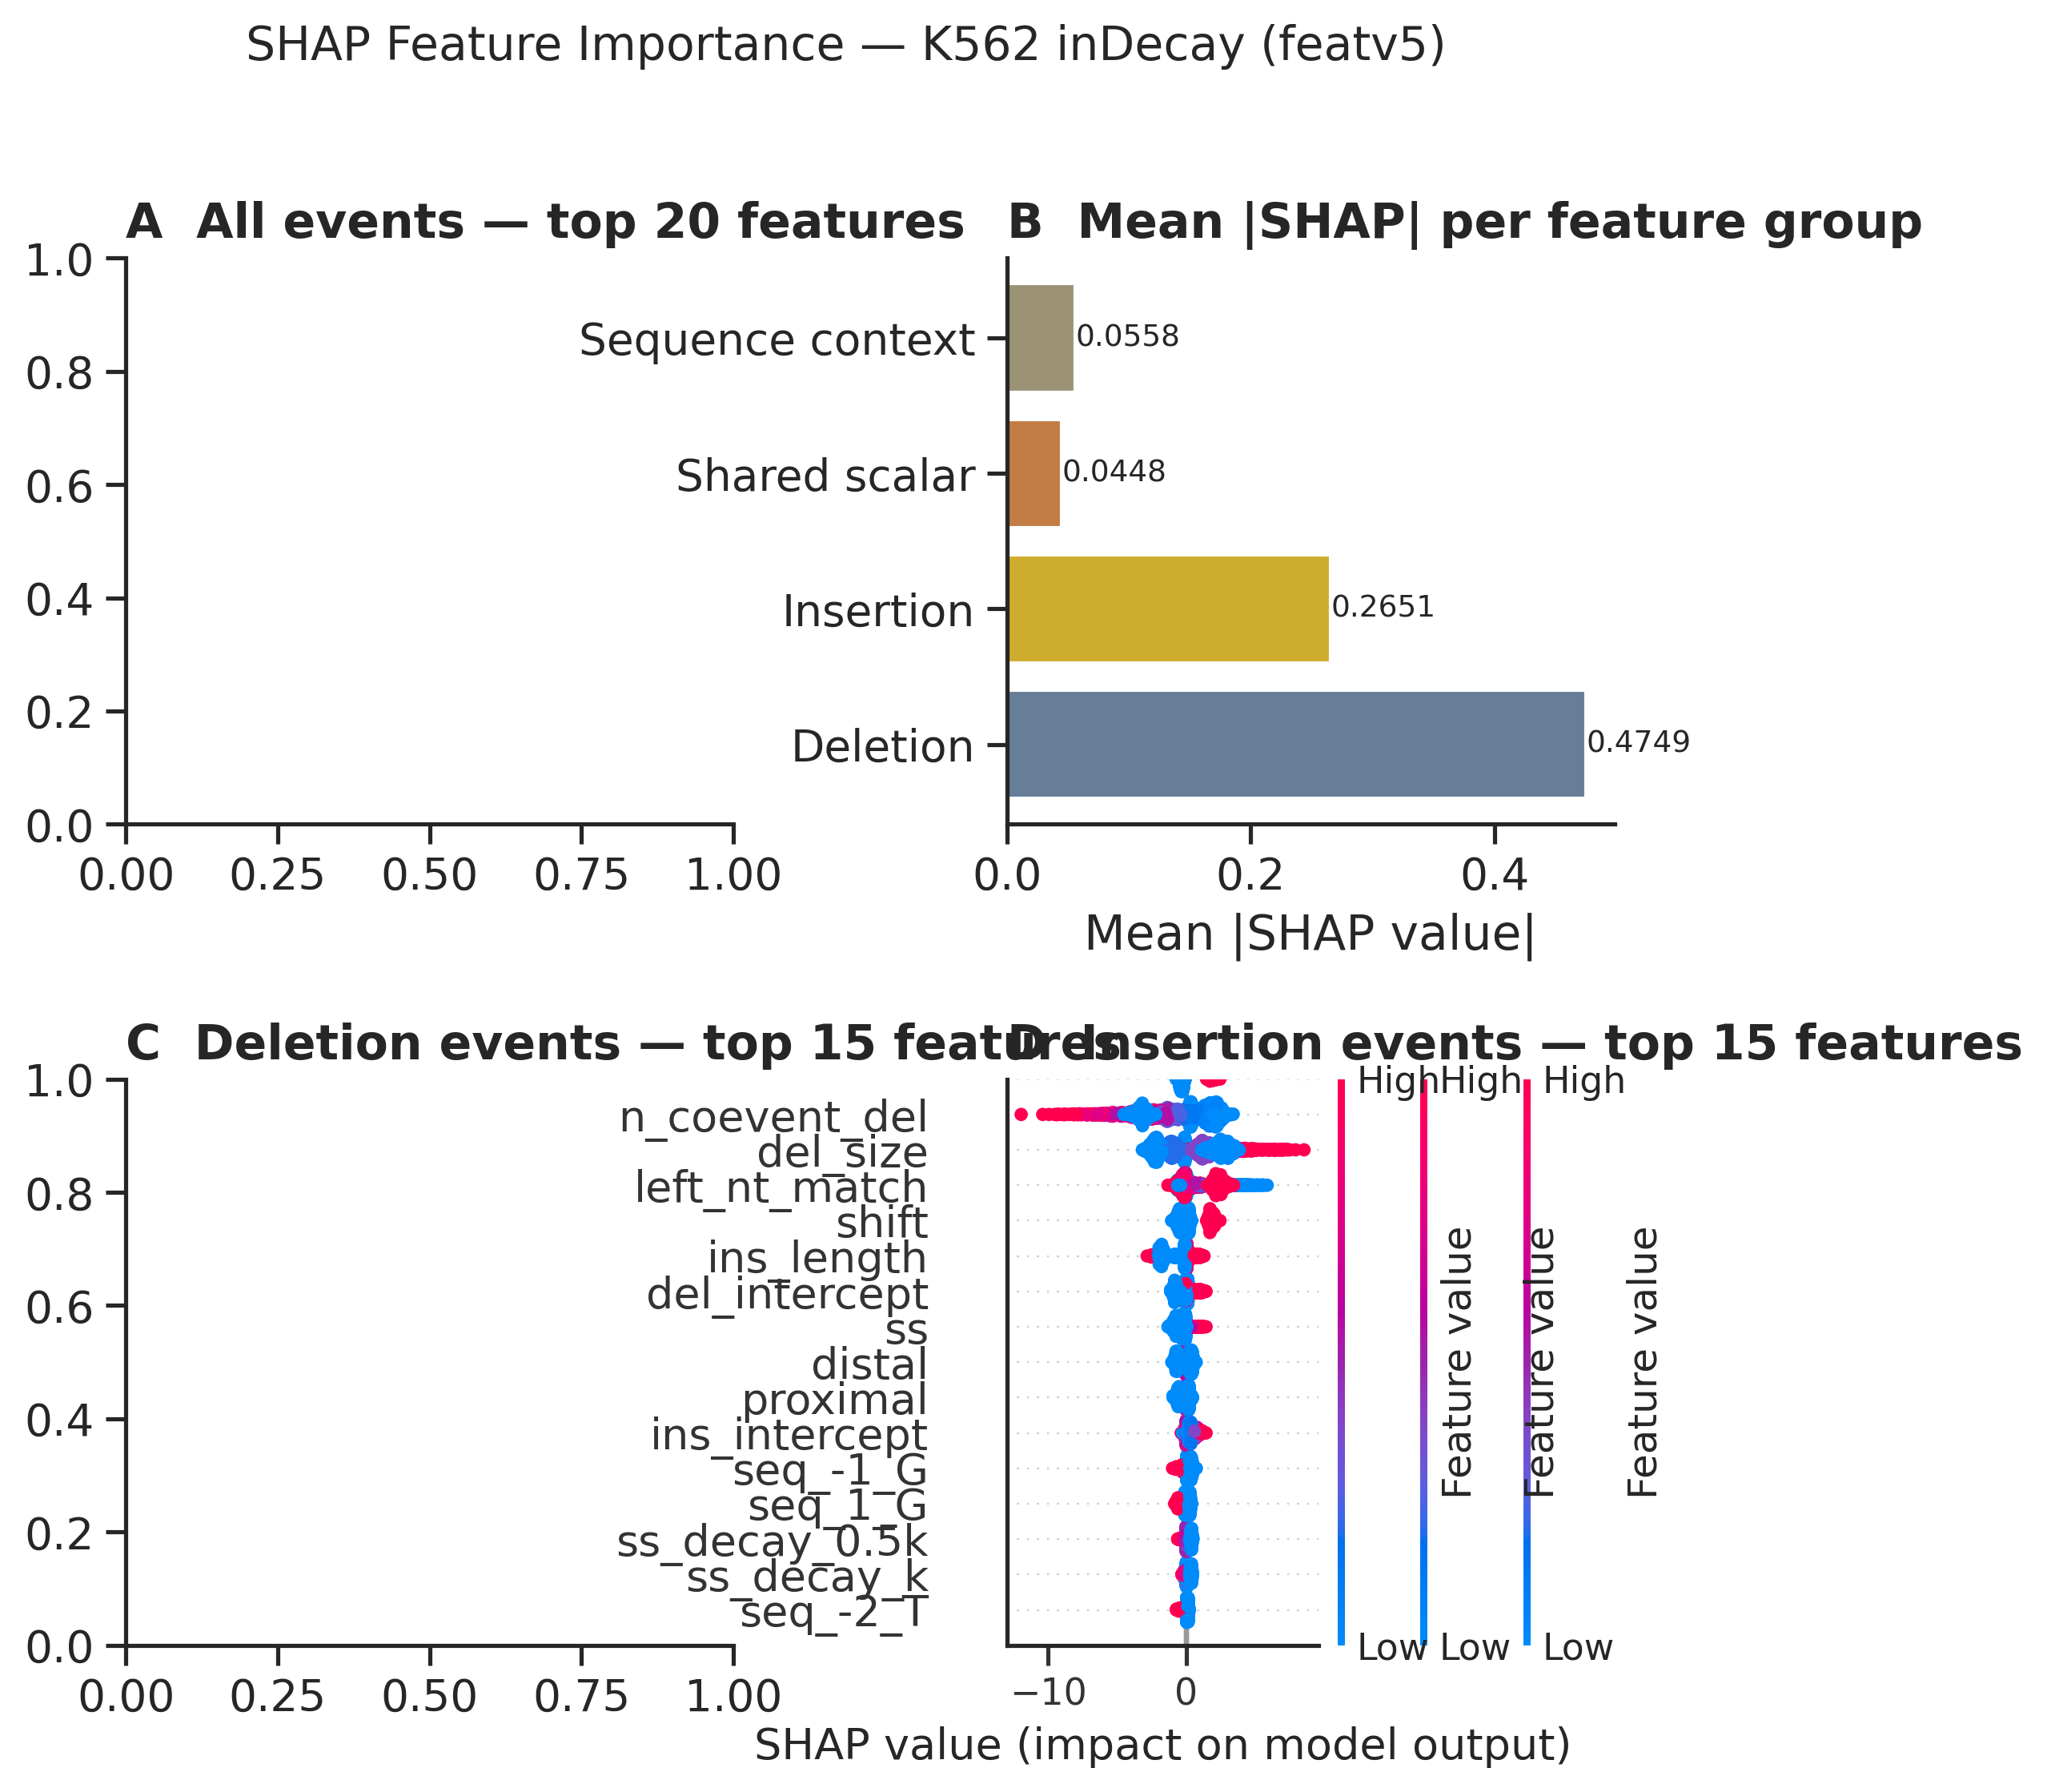

Saved: results/benchmarking/SHAP_K562_summary.pdf


In [49]:
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set theme
sns.set_theme(style='ticks', font_scale=1.2)

# Create figure and axes
fig, axs = plt.subplots(2, 2, figsize=(18, 14), dpi=300,
                        gridspec_kw={'hspace': 0.45, 'wspace': 0.45})

# Helper function to plot beeswarm on a specific axis
def plot_shap_beeswarm(ax, shap_vals, data, feat_names, title, max_display=20):
    """
    Plots a SHAP beeswarm plot on the given axis.
    """
    # Create Explanation object
    exp = shap.Explanation(
        values=shap_vals,
        data=data,
        feature_names=feat_names
    )
    
    # Plot using beeswarm
    # Note: In newer SHAP versions, passing ax is supported. 
    # If you still get the "plot_size" error, ensure you don't pass plot_size argument.
    try:
        shap.plots.beeswarm(
            exp,
            max_display=max_display,
            show=False,
            ax=ax,
            color_bar=True
        )
    except ValueError as e:
        # Fallback for strict versions: use summary_plot which might handle ax better in some contexts
        # or just plot without ax and copy (complex). 
        # Usually, removing explicit plot_size fixes it.
        print(f"Warning: {e}. Trying alternative plotting method...")
        shap.summary_plot(
            shap_vals,
            data,
            feature_names=feat_names,
            plot_type='dot',
            show=False,
            max_display=max_display,
            color_bar=True
        )
        # Grab the current axis and copy content? 
        # This is messy. Better to upgrade SHAP or stick to beeswarm with correct args.
        # For now, we assume the try block works if we don't pass conflicting args.
        pass

    ax.set_title(title, fontweight='bold', loc='left')
    sns.despine(ax=ax)

# ── Panel A: Beeswarm (all events, top 20 features) ───────────────────
ax_A = axs[0, 0]
plot_shap_beeswarm(
    ax=ax_A,
    shap_vals=shap_values[:, top_all],
    data=X_explain.numpy()[:, top_all],
    feat_names=[feature_names[i] for i in top_all],
    title='A  All events — top 20 features',
    max_display=20
)

# ── Panel B: Mean |SHAP| by feature group ─────────────────────────────
ax_B = axs[0, 1]
group_order = ['Deletion', 'Insertion', 'Shared scalar', 'Sequence context']
group_mean_abs = {}
for grp in group_order:
    idx = [i for i, g in enumerate(feat_group) if g == grp]
    group_mean_abs[grp] = np.abs(shap_values[:, idx]).mean()

grp_vals   = [group_mean_abs[g] for g in group_order]
grp_colors = [group_palette[g] for g in group_order]

bars = ax_B.barh(group_order, grp_vals, color=grp_colors, edgecolor='white')
ax_B.set_xlabel('Mean |SHAP value|')
ax_B.set_title('B  Mean |SHAP| per feature group', fontweight='bold', loc='left')
for bar, val in zip(bars, grp_vals):
    ax_B.text(val + 0.0005, bar.get_y() + bar.get_height() / 2,
              f'{val:.4f}', va='center', fontsize=9)
sns.despine(ax=ax_B)

# ── Panel C: Beeswarm (deletion events, top 15) ───────────────────────
ax_C = axs[1, 0]
plot_shap_beeswarm(
    ax=ax_C,
    shap_vals=shap_values[del_mask][:, top_del],
    data=X_explain.numpy()[del_mask][:, top_del],
    feat_names=[feature_names[i] for i in top_del],
    title='C  Deletion events — top 15 features',
    max_display=15
)

# ── Panel D: Beeswarm (insertion events, top 15) ──────────────────────
ax_D = axs[1, 1]
plot_shap_beeswarm(
    ax=ax_D,
    shap_vals=shap_values[ins_mask][:, top_ins],
    data=X_explain.numpy()[ins_mask][:, top_ins],
    feat_names=[feature_names[i] for i in top_ins],
    title='D  Insertion events — top 15 features',
    max_display=15
)

fig.suptitle('SHAP Feature Importance — K562 inDecay (featv5)', fontsize=14, y=1.01)

plt.savefig(
    f"{PATH.main_dir}/results/benchmarking/SHAP_K562_summary.pdf",
    format='pdf', bbox_inches='tight',
)
plt.show()
print("Saved: results/benchmarking/SHAP_K562_summary.pdf")

In [ ]:
# ── STUB: fill in when data is available ──────────────────────────────
# embryo_csv = f"{PATH.main_dir}/data/embryo_qc_data.csv"
# qc_df = pd.read_csv(embryo_csv)
# qc_df['survival_rate'] = qc_df['N_survived'] / qc_df['N_initial']
# qc_df['edit_rate']     = qc_df['N_edited']   / qc_df['N_survived']
# print(qc_df.describe())
# qc_df.to_csv(f"{PATH.main_dir}/results/benchmarking/embryo_QC_table.csv", index=False)
print("Embryo QC: waiting for data — see checklist above.")